## 0.データのフィルタリング・クリーニング 関数

### データ読み込みと結合

In [1]:
#csvファイルではなくtxtファイルを読み込む
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


path_1 = Path('../data/raw/trajectories-0400-0415.txt')
path_2 = Path('../data/raw/trajectories-0500-0515.txt')
path_3 = Path('../data/raw/trajectories-0515-0530.txt')

columns = [
    'Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X', 'Local_Y',
    'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class', 'v_Vel', 'v_Acc',
    'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway'
]

df_1 = pd.read_csv(path_1, sep=r'\s+', header=None, names=columns)
df_2 = pd.read_csv(path_2, sep=r'\s+', header=None, names=columns)
df_3 = pd.read_csv(path_3, sep=r'\s+', header=None, names=columns)

# 時間帯の識別列を追加 (id の重複があるため)
df_1['time_period'] = 1  # 4:00-4:15
df_2['time_period'] = 2  # 5:00-5:15
df_3['time_period'] = 3  # 5:15-5:30

# 結合
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

# データの確認
print(df.shape)
df.head()

(4566387, 19)


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway,time_period
0,1,12,884,1113433136100,16.884,48.213,6042842.116,2133117.662,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
1,1,13,884,1113433136200,16.938,49.463,6042842.012,2133118.909,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
2,1,14,884,1113433136300,16.991,50.712,6042841.908,2133120.155,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
3,1,15,884,1113433136400,17.045,51.963,6042841.805,2133121.402,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
4,1,16,884,1113433136500,17.098,53.213,6042841.701,2133122.649,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1


In [3]:
# 列名の確認
print(df.columns.tolist())

# データ型の確認
print(df.dtypes)

#欠損値　
print("\n欠損値:")
df.isnull().sum()

# 基本統計量
df.describe()

#v,accはfeet表示

['Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X', 'Local_Y', 'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class', 'v_Vel', 'v_Acc', 'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway', 'time_period']
Vehicle_ID         int64
Frame_ID           int64
Total_Frames       int64
Global_Time        int64
Local_X          float64
Local_Y          float64
Global_X         float64
Global_Y         float64
v_Length         float64
v_Width          float64
v_Class            int64
v_Vel            float64
v_Acc            float64
Lane_ID            int64
Preceding          int64
Following          int64
Space_Headway    float64
Time_Headway     float64
time_period        int64
dtype: object

欠損値:


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway,time_period
count,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06
mean,1.588199e+03,5.471980e+03,1.015003e+03,1.113437e+12,3.984736e+01,8.430695e+02,6.042761e+06,2.133909e+06,1.611579e+01,6.852992e+00,2.032801e+00,1.934866e+01,6.237478e-03,3.832722e+00,1.513829e+03,1.523074e+03,5.435219e+01,4.221553e+02,2.107550e+00
std,8.078982e+02,2.661235e+03,4.787489e+02,1.881963e+06,2.107819e+01,4.487661e+02,6.778314e+01,4.447039e+02,7.311574e+00,8.721375e-01,2.005007e-01,1.317379e+01,4.753486e+00,1.680516e+00,8.518476e+02,8.533007e+02,3.725520e+01,1.999911e+03,8.056143e-01
min,1.000000e+00,4.000000e+00,2.030000e+02,1.113433e+12,0.000000e+00,0.000000e+00,6.042587e+06,2.133040e+06,4.900000e+00,2.700000e+00,1.000000e+00,0.000000e+00,-1.120000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.540000e+02,3.237000e+03,6.750000e+02,1.113434e+12,1.895600e+01,4.651840e+02,6.042705e+06,2.133535e+06,1.380000e+01,6.300000e+00,2.000000e+00,9.780000e+00,-6.000000e-01,2.000000e+00,8.440000e+02,8.530000e+02,3.300000e+01,2.070000e+00,1.000000e+00
50%,1.642000e+03,5.712000e+03,8.900000e+02,1.113437e+12,4.113200e+01,8.188110e+02,6.042766e+06,2.133885e+06,1.480000e+01,6.900000e+00,2.000000e+00,1.792000e+01,0.000000e+00,4.000000e+00,1.584000e+03,1.592000e+03,4.638000e+01,2.980000e+00,2.000000e+00
75%,2.191000e+03,7.704000e+03,1.358000e+03,1.113438e+12,5.476500e+01,1.228128e+03,6.042818e+06,2.134291e+06,1.590000e+01,7.400000e+00,2.000000e+00,2.649000e+01,6.300000e-01,5.000000e+00,2.156000e+03,2.166000e+03,6.660000e+01,4.620000e+00,3.000000e+00
max,3.366000e+03,1.169100e+04,2.434000e+03,1.113439e+12,9.699600e+01,1.790771e+03,6.042911e+06,2.134845e+06,7.770000e+01,8.500000e+00,3.000000e+00,9.530000e+01,1.120000e+01,7.000000e+00,3.366000e+03,3.366000e+03,1.321550e+03,1.173390e+04,3.000000e+00


In [2]:
# 車種の分布確認
print("車種の分布:")
print(df['v_Class'].value_counts())

# 車線の分布確認
print("\n車線の分布:")
print(df['Lane_ID'].value_counts().sort_index())

車種の分布:
v_Class
2    4377903
3     169132
1      19352
Name: count, dtype: int64

車線の分布:
Lane_ID
1    404588
2    830690
3    719832
4    880189
5    785454
6    791237
7    154397
Name: count, dtype: int64


### 1.すべての追従ペアにペアIDと追従モード識別番号を付与　(df_with_pairsを作成)

In [4]:
#追従ペアIDを付与する関数
def give_pair_id(df):
    """
    追従ペアIDを付与する関数
    """
    # ソート
    df = df.sort_values(['time_period', 'Vehicle_ID', 'Global_Time']).copy()
    
    # 追従が途切れるタイミングを検出
    # 自分が車線(Lane_ID)変更
    lane_changed = df.groupby(['Vehicle_ID', 'time_period'])['Lane_ID'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    #先行車両(Preceding)が変わった（ほかの車が車線変更）
    preceding_changed = df.groupby(['Vehicle_ID', 'time_period'])['Preceding'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    #追従関係にない（Preceding=0）
    preceding_zero = df['Preceding'] == 0
    
    # 条件が途切れるタイミング
    break_point = lane_changed | preceding_changed | preceding_zero
    
    # ペアIDを付与
    df['pair_id'] = break_point.cumsum()
    
    # Preceding=0の行はpair_idをNaNにする
    df.loc[preceding_zero, 'pair_id'] = None
    
    return df


#追従ペアIDを付与する関数
def give_mode_id(df, original_df):
    """
    追従ペアにモードIDを付与する関数
    
    モードID（ego_class, leader_class）：
    (c-c)=1, (c-t)=2, (t-c)=3
    (t-t)=4, (others)=5,
    """
    mode_map = {
        (2,2): 1, (2,3): 2, (3,2): 3,
        (3,3): 4, (2,1): 5, (3,1): 5,
        (1,1): 5, (1,2): 5, (1,3): 5
    }
    
    # 元データから前方車両の車種を取得
    leader_class = original_df[['Vehicle_ID', 'v_Class','time_period']].drop_duplicates()
    leader_class = leader_class.rename(columns={'Vehicle_ID': 'Preceding', 'v_Class': 'leader_class'})
    
    # 結合
    df = df.merge(leader_class, on=['Preceding', 'time_period'], how='left')
    df['ego_class'] = df['v_Class']
    
    # モードIDを付与（NaNの場合はNoneを返す）
    def get_mode_id(row):
        if pd.isna(row['leader_class']):
            return None
        return mode_map.get((int(row['ego_class']), int(row['leader_class'])))
    
    df['mode_id'] = df.apply(get_mode_id, axis=1)
    
    # 確認
    pairs_count = df.dropna(subset=['pair_id']).groupby(['pair_id', 'mode_id']).size().reset_index()
    summary = pairs_count.groupby('mode_id').size()
    print("モードID別ペア数:")
    print(summary)
    
    return df

In [5]:
# 実行 ペアID付与
df_with_pairs = give_pair_id(df)

# 確認
print(f"総行数: {len(df_with_pairs):,}")
print(f"追従ペア数: {df_with_pairs['pair_id'].nunique():,}")


# 実行　ペアモード付与
df_with_mode = give_mode_id(df_with_pairs, df)

print(f"\n総行数: {len(df_with_mode):,}")
print(f"追従ペア数: {df_with_mode['pair_id'].nunique():,}")

総行数: 4,566,387
追従ペア数: 14,800
モードID別ペア数:
mode_id
1.0    13136
2.0      471
3.0      593
4.0       46
5.0      554
dtype: int64

総行数: 4,566,387
追従ペア数: 14,800


#### チェック

In [70]:
# テスト用の小さなデータを作成
test_data = {
    'Vehicle_ID': [1, 1, 1, 1, 1, 2, 2, 2, 2, 2],
    'Global_Time': [100, 200, 300, 400, 500, 100, 200, 300, 400, 500],
    'Lane_ID':     [2,   2,   3,   3,   3,   2,   2,   2,   2,   2],
    'Preceding':   [0,   0,   5,   5,   6,   1,   1,   1,   0,   1],
    'v_Class':     [2,   2,   2,   2,   2,   3,   3,   3,   3,   3],
    'time_period': [1,   1,   1,   1,   1,   1,   1,   1,   1,   1]
}
df_test = pd.DataFrame(test_data)

print("テストデータ:")
print(df_test)

# ペアID付与テスト
print("\n--- give_pair_id テスト ---")
df_test_pairs = give_pair_id(df_test)
print(df_test_pairs[['Vehicle_ID', 'Global_Time', 'Lane_ID', 'Preceding', 'pair_id']])

# モードID付与テスト
print("\n--- give_mode_id テスト ---")
df_test_mode = give_mode_id(df_test_pairs, df_test)
print(df_test_mode[['Vehicle_ID', 'Global_Time', 'Preceding', 'pair_id', 'mode_id']])

テストデータ:
   Vehicle_ID  Global_Time  Lane_ID  Preceding  v_Class  time_period
0           1          100        2          0        2            1
1           1          200        2          0        2            1
2           1          300        3          5        2            1
3           1          400        3          5        2            1
4           1          500        3          6        2            1
5           2          100        2          1        3            1
6           2          200        2          1        3            1
7           2          300        2          1        3            1
8           2          400        2          0        3            1
9           2          500        2          1        3            1

--- give_pair_id テスト ---
   Vehicle_ID  Global_Time  Lane_ID  Preceding  pair_id
0           1          100        2          0      NaN
1           1          200        2          0      NaN
2           1          300        3    

### 追従関係のある車両だけのdfを作る

In [6]:
def filter_valid_pairs(df):
    """
    pair_idとmode_idが付与されている行のみ残す関数
    （追従関係がない行を除外）
    """
    df_filtered = df.dropna(subset=['pair_id', 'mode_id'])
    
    print(f"フィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_valid = filter_valid_pairs(df_with_mode)

フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,292
除外された行数: 207,095

ペア数: 14,800


### 車線フィルタ

In [7]:
def filter_lane(df, lanes=[2, 3, 4]):
    """
    車線フィルタ
    lanes: 使用する車線のリスト（デフォルト: Lane 2,3,4）
    """
    df_filtered = df[df['Lane_ID'].isin(lanes)]
    
    print(f"フィルタ前: {len(df):,}行")
    print(f"フィルタ後: {len(df_filtered):,}行")
    print(f"除外された行数: {len(df) - len(df_filtered):,}行")
    print(f"\n車線の分布:")
    print(df_filtered['Lane_ID'].value_counts().sort_index())
    
    return df_filtered

In [8]:
# 実行
df_lane_with_pairs = filter_lane(df_with_pairs)

# 追従ペア数の確認
print(f"追従ペア数: {df_lane_with_pairs['pair_id'].nunique():,}")

フィルタ前: 4,566,387行
フィルタ後: 2,430,711行
除外された行数: 2,135,676行

車線の分布:
Lane_ID
2    830690
3    719832
4    880189
Name: count, dtype: int64
追従ペア数: 6,218


### 車種フィルタ

In [10]:
def filter_mode(df, modes=[1,2,3,4]):
    """
    特定のモードIDのみを残すフィルタ（ペア単位で安全に処理）
    modes: 使用するモードIDのリスト
    デフォルト: [1,2,3,4]
    """
    
    # 1. 各ペアIDの代表モードIDを取得（最初の行の値を使う）
    pair_modes = df.dropna(subset=['pair_id']).groupby('pair_id')['mode_id'].first()
    
    # 2. 指定したモード(1,2,3,4)に該当する「ペアIDのリスト」を作成
    valid_pair_ids = pair_modes[pair_modes.isin(modes)].index
    
    # 3. 元のデータから、その有効なペアIDの行を丸ごと残す
    df_filtered = df[df['pair_id'].isin(valid_pair_ids)]
    
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"除外されたペア数: {df['pair_id'].nunique() - df_filtered['pair_id'].nunique():,}")
    print(f"\nモードID別ペア数:")
    pairs_count = df_filtered.groupby(['pair_id', 'mode_id']).size().reset_index()
    print(pairs_count.groupby('mode_id').size())
    
    return df_filtered

# 実行（モードIDが5のペアを除外）
df_mode_filtered = filter_mode(df_valid)

フィルタ前のペア数: 14,800
フィルタ後のペア数: 14,246
除外されたペア数: 554

モードID別ペア数:
mode_id
1.0    13136
2.0      471
3.0      593
4.0       46
dtype: int64


In [11]:
print(df_mode_filtered['v_Class'].value_counts())
print(f"\nLane 2,3,4のバイク数:")
print(len(df_mode_filtered[(df_mode_filtered['Lane_ID'].isin([2,3,4])) & (df_mode_filtered['v_Class'] == 1)]))

v_Class
2    4165920
3     158209
Name: count, dtype: int64

Lane 2,3,4のバイク数:
0


In [12]:
# 追従タイプを定義
def get_pair_type(ego, leader):
    class_map = {2: 'C', 3: 'T', 1: 'M'}
    ego_name = class_map.get(ego, '?')
    leader_name = class_map.get(leader, '?')
    return f'{ego_name}-{leader_name}'

df_mode_filtered['pair_type'] = df_mode_filtered.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['C-C', 'C-T', 'C-M', 'T-T', 'T-C', 'T-M', 'M-M', 'M-C', 'M-T']

# ペア数の集計
pairs_count = df_mode_filtered.dropna(subset=['pair_id']).groupby(['pair_id', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order, fill_value=0)

print("追従ペア数:")
print(pairs_summary)

追従ペア数:
pair_type
C-C    13136
C-T      471
C-M        0
T-T       46
T-C      593
T-M        0
M-M        0
M-C        0
M-T        0
dtype: int64


### 追従時間フィルタ

In [29]:
def filter_duration(df, min_duration=60):
    """
    追従時間フィルタ
    min_duration: 最小追従時間（秒）（デフォルト: 60秒）
    """
    # 各ペアの追従時間を計算
    pair_duration = df.groupby('pair_id')['Global_Time'].agg(
        duration=lambda x: (x.max() - x.min()) / 1000  # ミリ秒→秒
    )
    
    # min_duration以上のペアIDを取得
    valid_pair_ids = pair_duration[pair_duration['duration'] >= min_duration].index
    
    # 有効なペアIDの行だけ残す
    df_filtered = df[df['pair_id'].isin(valid_pair_ids)]
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"除外されたペア数: {df['pair_id'].nunique() - df_filtered['pair_id'].nunique():,}")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    
    return df_filtered

# df_lane_with_pairsに対して実行
df_duration = filter_duration(df_mode_filtered, min_duration=60)

フィルタ前のペア数: 14,246
フィルタ後のペア数: 2,102
除外されたペア数: 12,144

フィルタ前の行数: 4,324,129
フィルタ後の行数: 1,965,296


In [30]:
# 追従タイプを定義
def get_pair_type(ego, leader):
    class_map = {2: 'C', 3: 'T', 1: 'M'}
    ego_name = class_map.get(ego, '?')
    leader_name = class_map.get(leader, '?')
    return f'{ego_name}-{leader_name}'

df_duration['pair_type'] = df_duration.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['C-C', 'C-T', 'C-M', 'T-T', 'T-C', 'T-M', 'M-M', 'M-C', 'M-T']

# ペア数の集計
pairs_count = df_duration.dropna(subset=['pair_id']).groupby(['pair_id', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order, fill_value=0)

print("追従ペア数:")
print(pairs_summary)

追従ペア数:
pair_type
C-C    1967
C-T      72
C-M       0
T-T       6
T-C      57
T-M       0
M-M       0
M-C       0
M-T       0
dtype: int64


In [14]:
# ペアごとの追従時間の分布を確認
pair_times = df_duration.groupby('pair_id')['Global_Time'].agg(
    duration=lambda x: (x.max() - x.min()) / 1000
)
print(pair_times['duration'].describe())
print(f"\n60秒以下のペア数: {len(pair_times[pair_times['duration'] == 60]):,}")

count    2102.000000
mean       93.396480
std        34.741686
min        60.000000
25%        68.000000
50%        80.300000
75%       105.675000
max       217.000000
Name: duration, dtype: float64

60秒以下のペア数: 5


### 加速度フィルタ
加速度・減速度が1m/s^2 を超えた部分のみを削除する  <br>
NGSIMの単位: feet/s^2<br>
1 feet = 0.3048 m , 1 m = 3.28084 feet<br>
よって、1m/s^2 / 0.3048 = 3.28084 feet /s^2 を超える部分を削除する


In [15]:
def filter_acceleration(df, max_acc=1.0):
    """
    加速度フィルタ
    max_acc: 最大加速度・減速度（m/s²）（デフォルト: 1.0 m/s²）
    """
    # 閾値をfeet/s²に変換
    max_acc_feet = max_acc / 0.3048
    
    # 閾値を超える行を除外
    df_filtered = df[df['v_Acc'].abs() <= max_acc_feet]
    
    print(f"閾値: {max_acc} m/s² = {max_acc_feet:.4f} feet/s²")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nフィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_acc = filter_acceleration(df_duration)

閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,965,296
フィルタ後の行数: 1,437,993
除外された行数: 527,303

フィルタ前のペア数: 2,102
フィルタ後のペア数: 2,102


### カットオフウィンドウ

In [16]:
def apply_cutoff(df, cutoff=10):
    """
    カットオフウィンドウ
    cutoff: カットオフ時間（秒）（デフォルト: 10秒）
    """
    cutoff_ms = cutoff * 1000  # 秒→ミリ秒
    
    # ペアごとの最小・最大時刻を計算
    pair_times = df.groupby('pair_id')['Global_Time'].agg(
        min_time='min',
        max_time='max'
    ).reset_index()
    
    # 元のデータに結合
    df_merged = df.merge(pair_times, on='pair_id')
    
    # カットオフ条件でフィルタリング
    df_filtered = df_merged[
        (df_merged['Global_Time'] >= df_merged['min_time'] + cutoff_ms) &
        (df_merged['Global_Time'] <= df_merged['max_time'] - cutoff_ms)
    ].drop(columns=['min_time', 'max_time'])
    
    print(f"カットオフ前の行数: {len(df):,}")
    print(f"カットオフ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nカットオフ前のペア数: {df['pair_id'].nunique():,}")
    print(f"カットオフ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_cutoff = apply_cutoff(df_acc)

カットオフ前の行数: 1,437,993
カットオフ後の行数: 1,156,045
除外された行数: 281,948

カットオフ前のペア数: 2,102
カットオフ後のペア数: 2,102


In [17]:
# ペアごとの追従時間の分布を確認
pair_times = df_cutoff.groupby('pair_id')['Global_Time'].agg(
    duration=lambda x: (x.max() - x.min()) / 1000
)
print(pair_times['duration'].describe())
print(f"\n60秒以下のペア数: {len(pair_times[pair_times['duration'] < 38]):,}")

count    2102.000000
mean       73.000143
std        34.786220
min        38.300000
25%        47.600000
50%        59.600000
75%        85.300000
max       196.900000
Name: duration, dtype: float64

60秒以下のペア数: 0


#### 車線変更の確認 不要な気がする

In [18]:
def filter_lane_change(df):
    """
    車線変更フィルタ
    同じVehicle_ID・time_periodで車線変更が含まれる車両のペアを除外する
    """
    # Vehicle_ID・time_periodごとにLane_IDが変化しているか確認
    lane_changed_vehicles = df.groupby(['Vehicle_ID', 'time_period'])['Lane_ID'].apply(
        lambda x: x.nunique() > 1
    )
    
    # 車線変更があったVehicle_ID・time_periodを取得
    invalid = lane_changed_vehicles[lane_changed_vehicles].reset_index()[['Vehicle_ID', 'time_period']]
    
    # 該当する車両が含まれるpair_idを取得
    invalid_pairs = df.merge(invalid, on=['Vehicle_ID', 'time_period'], how='inner')['pair_id'].unique()
    
    # 無効なペアを除外
    df_filtered = df[~df['pair_id'].isin(invalid_pairs)]
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"除外されたペア数: {len(invalid_pairs):,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    
    return df_filtered

# テストデータで確認
print("--- filter_lane_change テスト ---")
df_test_lc = filter_lane_change(df_cutoff)
print(df_test_lc[['Vehicle_ID', 'Global_Time', 'Lane_ID', 'Preceding', 'pair_id', 'mode_id']])

--- filter_lane_change テスト ---
フィルタ前のペア数: 2,102
除外されたペア数: 36
フィルタ後のペア数: 2,066

フィルタ前の行数: 1,156,045
フィルタ後の行数: 1,138,748
         Vehicle_ID    Global_Time  Lane_ID  Preceding   pair_id  mode_id
58               11  1113433150600        2          1    2258.0      1.0
59               11  1113433150700        2          1    2258.0      1.0
60               11  1113433150800        2          1    2258.0      1.0
61               11  1113433150900        2          1    2258.0      1.0
62               11  1113433151000        2          1    2258.0      1.0
...             ...            ...      ...        ...       ...      ...
1437926        3006  1113437859900        4        479  221676.0      1.0
1437927        3006  1113437860000        4        479  221676.0      1.0
1437928        3006  1113437860100        4        479  221676.0      1.0
1437929        3006  1113437860200        4        479  221676.0      1.0
1437930        3006  1113437860300        4        479  221676.0   

### 確認

In [38]:
# ① ペアID付与
df_with_pairs = give_pair_id(df)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")

モードID別ペア数:
mode_id
1.0    13136
2.0      471
3.0      593
4.0       46
5.0      554
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,292
除外された行数: 207,095

ペア数: 14,800
フィルタ前: 4,359,292行
フィルタ後: 2,338,989行
除外された行数: 2,020,303行

車線の分布:
Lane_ID
2    800434
3    689328
4    849227
Name: count, dtype: int64
フィルタ前のペア数: 6,218
フィルタ後のペア数: 6,053
除外されたペア数: 165

モードID別ペア数:
mode_id
1.0    5400
2.0     259
3.0     355
4.0      39
dtype: int64
フィルタ前のペア数: 6,053
フィルタ後のペア数: 1,535
除外されたペア数: 4,518

フィルタ前の行数: 2,335,404
フィルタ後の行数: 1,456,062
カットオフ前の行数: 1,456,062
カットオフ後の行数: 1,149,062
除外された行数: 307,000

カットオフ前のペア数: 1,535
カットオフ後のペア数: 1,535
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,149,062
フィルタ後の行数: 863,661
除外された行数: 285,401

フィルタ前のペア数: 1,535
フィルタ後のペア数: 1,535

===最終結果===
行数: 863,661
ペア数: 1,535


In [39]:
# 追従タイプを定義
def get_pair_type(ego, leader):
    class_map = {2: 'C', 3: 'T', 1: 'M'}
    ego_name = class_map.get(ego, '?')
    leader_name = class_map.get(leader, '?')
    return f'{ego_name}-{leader_name}'

df_final['pair_type'] = df_final.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['C-C', 'C-T', 'C-M', 'T-T', 'T-C', 'T-M', 'M-M', 'M-C', 'M-T']

# ペア数の集計
pairs_count = df_final.dropna(subset=['pair_id']).groupby(['pair_id', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order, fill_value=0)
trajectory_summary = df_final.groupby('pair_type').size().reindex(order, fill_value=0)

print("追従ペア数:")
print(pairs_summary)
print("\n軌跡データ件数:")
print(trajectory_summary)

追従ペア数:
pair_type
C-C    1421
C-T      60
C-M       0
T-T       6
T-C      48
T-M       0
M-M       0
M-C       0
M-T       0
dtype: int64

軌跡データ件数:
pair_type
C-C    800017
C-T     34156
C-M         0
T-T      3776
T-C     25712
T-M         0
M-M         0
M-C         0
M-T         0
dtype: int64


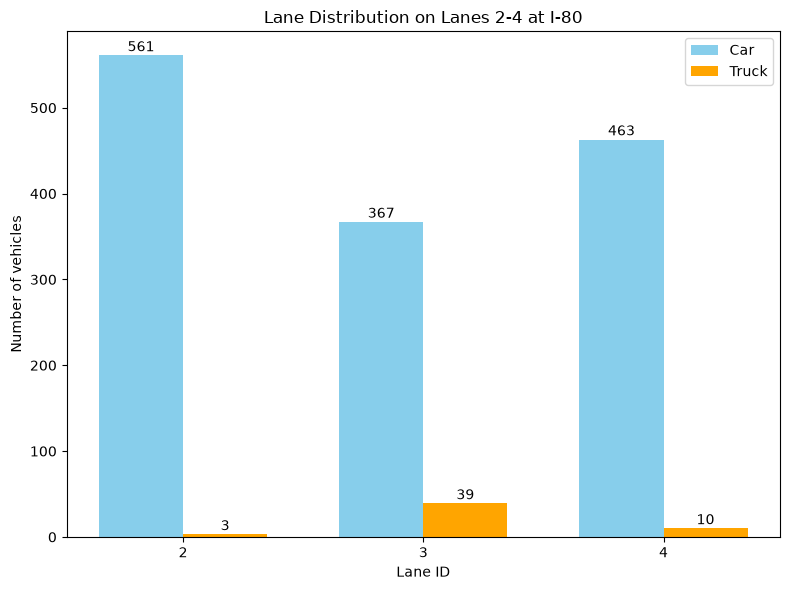

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 解析に使うベースデータを明示的に定義
base_df = df_cutoff.copy()

# ★修正1：Lane 2, 3, 4 のデータだけに絞り込む
base_df = base_df[base_df['Lane_ID'].isin([2, 3, 4])]

# 車線ごとの車両数を集計
base_df = base_df.drop_duplicates(subset=['Vehicle_ID', 'time_period', 'Lane_ID'])
lane_class = base_df.groupby(['Lane_ID', 'v_Class'])['Vehicle_ID'].nunique().reset_index()

# ★修正2：pivotを使って行をLane_ID、列をv_Classのクロス集計表にする
# （データがない組み合わせは fillna(0) で0台として埋める）
pivot_df = lane_class.pivot(index='Lane_ID', columns='v_Class', values='Vehicle_ID').fillna(0)

# グラフ描画
x = pivot_df.index.to_numpy() # [2, 3, 4] が自動で入る
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

# ★修正3：抽出したpivotの表から安全に値を取り出す
# （万が一、車かトラックのどちらかが0台で列が存在しなくてもエラーを回避）
cars_vals = pivot_df[2].values if 2 in pivot_df.columns else np.zeros(len(x))
trucks_vals = pivot_df[3].values if 3 in pivot_df.columns else np.zeros(len(x))

bars_car = ax.bar(x - width/2, cars_vals, width, label='Car', color='skyblue')
bars_truck = ax.bar(x + width/2, trucks_vals, width, label='Truck', color='orange')

# 値をバーの上に表示
for bar in bars_car:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

for bar in bars_truck:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

ax.set_xlabel('Lane ID')
ax.set_ylabel('Number of vehicles')
ax.set_xticks(x)
ax.legend()
ax.set_title('Lane Distribution on Lanes 2-4 at I-80')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# テスト用データセット作成
np.random.seed(42)

n = 100
test_data = {
    'Vehicle_ID': [1]*40 + [2]*35 + [3]*25,
    'Frame_ID': list(range(100, 140)) + list(range(100, 135)) + list(range(100, 125)),
    'Global_Time': [1113433100 + i*100 for i in range(40)] + 
                   [1113433100 + i*100 for i in range(35)] + 
                   [1113433100 + i*100 for i in range(25)],
    'Lane_ID': [2]*20 + [3]*20 + [2]*35 + [4]*25,
    'Preceding': [0]*5 + [10]*15 + [11]*10 + [12]*10 + 
                 [0]*5 + [20]*30 + 
                 [0]*5 + [30]*20,
    'v_Class': [2]*40 + [3]*35 + [2]*25,
    'v_Vel': np.random.uniform(10, 30, 100),
    'v_Acc': np.random.uniform(-1, 1, 100),
    'Space_Headway': np.random.uniform(5, 30, 100),
    'Time_Headway': np.random.uniform(0.5, 3, 100),
    'time_period': [1]*100
}

df_test = pd.DataFrame(test_data)

# テキストファイルに出力
df_test.to_csv('../data/raw/test_data.txt', sep='\t', index=False)

print(f"出力行数: {len(df_test):,}行")
print("出力先: ../data/raw/test_data.txt")
print(df_test.head(10))

出力行数: 100行
出力先: ../data/raw/test_data.txt
   Vehicle_ID  Frame_ID  Global_Time  Lane_ID  Preceding  v_Class      v_Vel  \
0           1       100   1113433100        2          0        2  17.490802   
1           1       101   1113433200        2          0        2  29.014286   
2           1       102   1113433300        2          0        2  24.639879   
3           1       103   1113433400        2          0        2  21.973170   
4           1       104   1113433500        2          0        2  13.120373   
5           1       105   1113433600        2         10        2  13.119890   
6           1       106   1113433700        2         10        2  11.161672   
7           1       107   1113433800        2         10        2  27.323523   
8           1       108   1113433900        2         10        2  22.022300   
9           1       109   1113434000        2         10        2  24.161452   

      v_Acc  Space_Headway  Time_Headway  time_period  
0 -0.937142      21.0

In [42]:
# mode_idとラベルの対応
mode_label = {1: 'C-C', 2: 'C-T', 3: 'T-C', 4: 'T-T', 5: 'Others'}

# 出力順番
order = ['C-C', 'C-T', 'T-C', 'T-T', 'Others']

# ペア数の集計
pairs_count = df_final.dropna(subset=['pair_id']).groupby(['pair_id', 'mode_id']).size().reset_index()
pairs_count['mode_label'] = pairs_count['mode_id'].map(mode_label)
pairs_summary = pairs_count.groupby('mode_label').size().reindex(order, fill_value=0)

# 軌跡データ件数
df_final['mode_label'] = df_final['mode_id'].map(mode_label)
trajectory_summary = df_final.dropna(subset=['pair_id']).groupby('mode_label').size().reindex(order, fill_value=0)

print("追従ペア数:")
print(pairs_summary)
print("\n軌跡データ件数:")
print(trajectory_summary)

追従ペア数:
mode_label
C-C       1421
C-T         60
T-C         48
T-T          6
Others       0
dtype: int64

軌跡データ件数:
mode_label
C-C       800017
C-T        34156
T-C        25712
T-T         3776
Others         0
dtype: int64
